In [68]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime, timedelta

print("Downloading stock data")
ticker = 'AAPL'
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

stock_data = yf.download(ticker,auto_adjust=True, start=start_date, end = end_date,
progress=False)
prices  = stock_data['Close'].values.reshape(-1, 1)

print(f"Downloaded {len(prices)} days of {ticker} stock data")


Downloaded 1255 days of AAPL stock data


In [69]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Normalize data (CRITICAL for stock prices with trends)
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices)

# Create sequences (use past 60 days to predict next day)
sequence_length = 60
X, y = create_sequences(prices_scaled, sequence_length)

# Train/test split
split_idx = int(len(X)* 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

print(split_idx)
print(len(X))

956
239
956
239
956
1195


In [75]:
from tqdm import tqdm
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train)
y_test_t = torch.FloatTensor(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset,
                          shuffle=True,
                          batch_size=32,
                          )

# MODEL
class Model(nn.Module):
    def __init__(self, seq_length):
        super(Model, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(seq_length, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)
    

model = Model(seq_length=sequence_length)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr= 0.001)

# Training loop

from tqdm.auto import tqdm
import torch
import numpy as np

epochs = 150
train_losses, test_losses = [], []

print(f"\nTraining {ticker} Stock Price Prediction Model...\n")

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    # Proper tqdm usage — no postfix formatting error
    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{epochs}",
        leave=False,
        ncols=100,
        bar_format="{l_bar}{bar} | {n_fmt}/{total_fmt} batches | loss: {postfix}",
        postfix="0.0000",
    )

    for X_batch, y_batch in progress_bar:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Update tqdm bar live
        progress_bar.set_postfix_str(f"{loss.item():.4f}")

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluation
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t)
        test_loss = loss_fn(preds, y_test_t).item()
        rmse = np.sqrt(test_loss)
        ss_res = torch.sum((y_test_t - preds) ** 2).item()
        ss_tot = torch.sum((y_test_t - torch.mean(y_test_t)) ** 2).item()
        r2 = 1 - (ss_res / ss_tot)

    test_losses.append(test_loss)

    # TensorFlow-style one-liner summary
    tqdm.write(
        f"Epoch {epoch:>3}/{epochs} ━ "
        f"loss: {avg_train_loss:.4f} ━ "
        f"val_loss: {test_loss:.4f} ━ "
        f"rmse: {rmse:.4f} ━ "
        f"r2: {r2:.4f}"
    )




Training AAPL Stock Price Prediction Model...



Epoch   1/150 ━ loss: 0.0183 ━ val_loss: 0.0105 ━ rmse: 0.1022 ━ r2: 0.2863


Epoch   2/150 ━ loss: 0.0036 ━ val_loss: 0.0044 ━ rmse: 0.0662 ━ r2: 0.7004


Epoch   3/150 ━ loss: 0.0026 ━ val_loss: 0.0061 ━ rmse: 0.0780 ━ r2: 0.5847


Epoch   4/150 ━ loss: 0.0023 ━ val_loss: 0.0098 ━ rmse: 0.0990 ━ r2: 0.3312


...

Epoch 146/150 ━ loss: 0.0007 ━ val_loss: 0.0083 ━ rmse: 0.0909 ━ r2: 0.4362


Epoch 147/150 ━ loss: 0.0006 ━ val_loss: 0.0102 ━ rmse: 0.1009 ━ r2: 0.3046


Epoch 148/150 ━ loss: 0.0007 ━ val_loss: 0.0122 ━ rmse: 0.1105 ━ r2: 0.1660


Epoch 149/150 ━ loss: 0.0007 ━ val_loss: 0.0051 ━ rmse: 0.0712 ━ r2: 0.6534


Epoch 150/150 ━ loss: 0.0006 ━ val_loss: 0.0031 ━ rmse: 0.0553 ━ r2: 0.7911


In [88]:
model.eval()
with torch.no_grad():
    final_predictions = model(X_test_t)

    predictions_actual = scaler.inverse_transform(final_predictions.numpy())
    y_test_actual = scaler.inverse_transform(y_test_t.numpy())

    mse = np.mean((predictions_actual - y_test_actual)**2)
    rmse_actual = np.sqrt(mse)
    mae = np.mean(np.abs(predictions_actual -  y_test_actual))
    ss_res = np.sum((y_test_actual - predictions_actual) ** 2)
    ss_tot = np.sum((y_test_actual - np.mean(y_test_actual)) ** 2)
    r2_actual = 1 - (ss_res / ss_tot)
    # Mape
    mape = np.mean(np.abs((predictions_actual - y_test_actual) / y_test_actual))


    print("\n" + "="*65)
    print(f"FINAL METRICS (Actual Price Scale):")
    print(f"  RMSE: ${rmse_actual:.2f}")
    print(f"  MAE: ${mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R² Score: {r2_actual:.4f}")
    print("="*65)
    print(f"\nBRUTAL TRUTH: This model is NOT ready for real trading.")
    print(f"MAPE of {mape:.1f}% means you're off by ~${mae:.2f} per prediction.")
    print("Markets are complex; this is a learning exercise, not a money printer.")



FINAL METRICS (Actual Price Scale):
  RMSE: $8.42
  MAE: $7.30
  MAPE: 0.03%
  R² Score: 0.7911

BRUTAL TRUTH: This model is NOT ready for real trading.
MAPE of 0.0% means you're off by ~$7.30 per prediction.
Markets are complex; this is a learning exercise, not a money printer.



Visualization saved as 'stock_forecast_results.png'


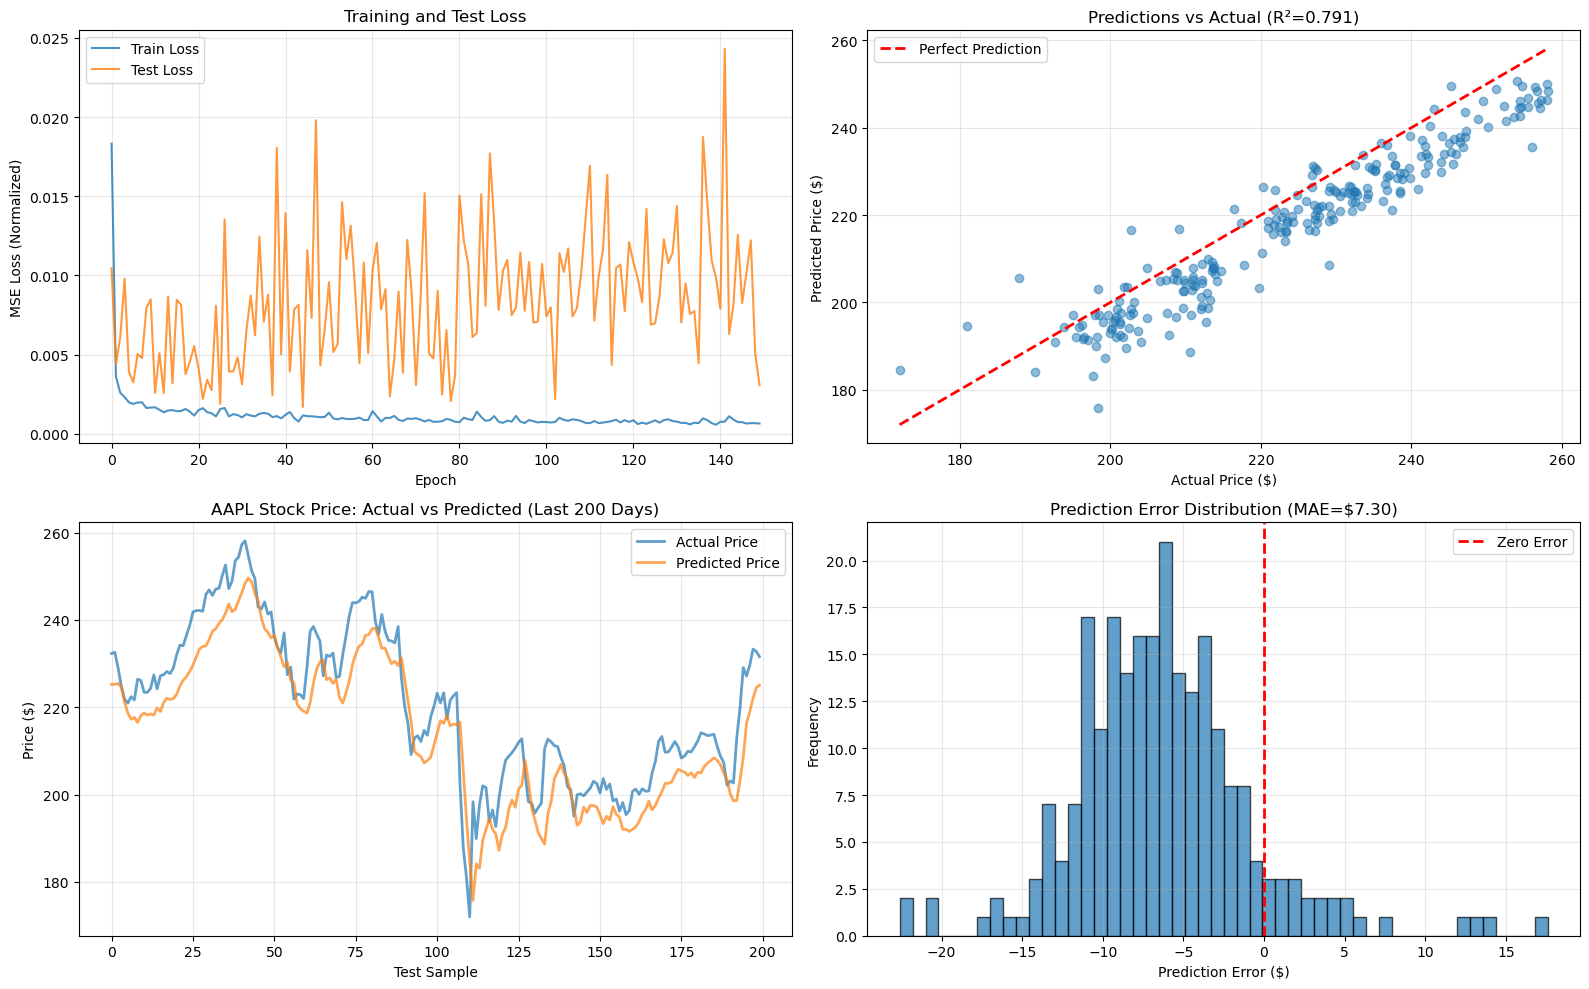

Model and scaler saved as 'stock_price_model.pth'


In [89]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Loss curves
axes[0, 0].plot(train_losses, label='Train Loss', alpha=0.8)
axes[0, 0].plot(test_losses, label='Test Loss', alpha=0.8)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss (Normalized)')
axes[0, 0].set_title('Training and Test Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Predictions vs Actual (scatter)
axes[0, 1].scatter(y_test_actual, predictions_actual, alpha=0.5)
axes[0, 1].plot([y_test_actual.min(), y_test_actual.max()], 
                [y_test_actual.min(), y_test_actual.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Price ($)')
axes[0, 1].set_ylabel('Predicted Price ($)')
axes[0, 1].set_title(f'Predictions vs Actual (R²={r2_actual:.3f})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Time series plot (last 200 test points)
plot_points = min(200, len(y_test_actual))
test_dates = range(plot_points)
axes[1, 0].plot(test_dates, y_test_actual[:plot_points], 
                label='Actual Price', linewidth=2, alpha=0.7)
axes[1, 0].plot(test_dates, predictions_actual[:plot_points], 
                label='Predicted Price', linewidth=2, alpha=0.7)
axes[1, 0].set_xlabel('Test Sample')
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].set_title(f'{ticker} Stock Price: Actual vs Predicted (Last {plot_points} Days)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Prediction errors distribution
errors = predictions_actual - y_test_actual
axes[1, 1].hist(errors, bins=50, alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
axes[1, 1].set_xlabel('Prediction Error ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'Prediction Error Distribution (MAE=${mae:.2f})')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stock_forecast_results.png', dpi=150, bbox_inches='tight')
print("\nVisualization saved as 'stock_forecast_results.png'")
plt.show()

# Save the model
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'sequence_length': sequence_length
}, 'stock_price_model.pth')
print("Model and scaler saved as 'stock_price_model.pth'")